<Axes: >

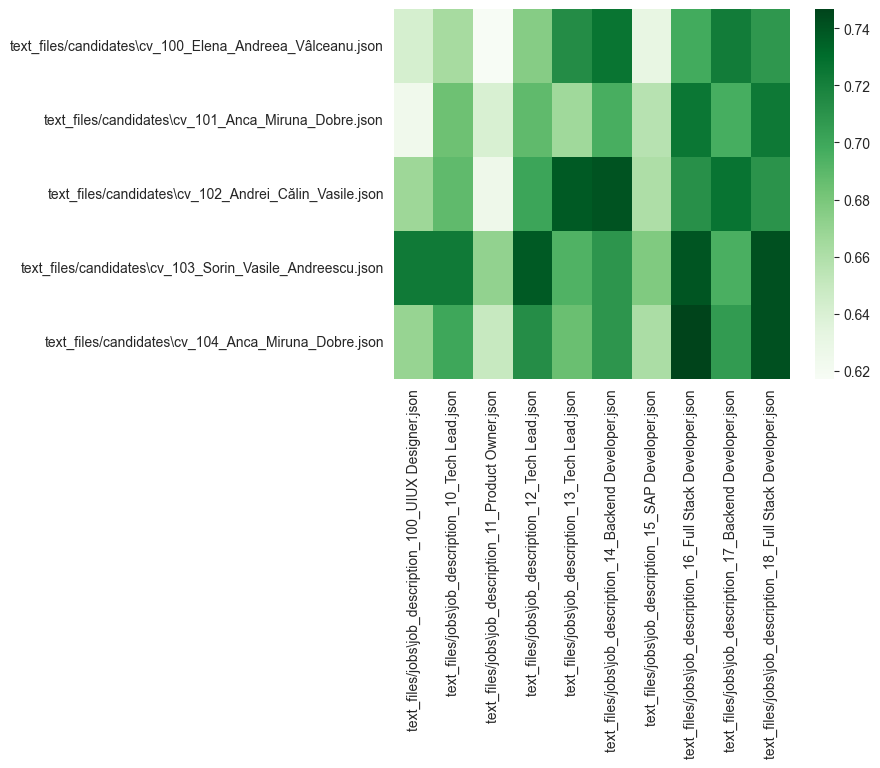

In [4]:
from google import genai
from google.genai import types

from scripts.json_matcher import read_folder

GOOGLE_API_KEY = ''
client = genai.Client(api_key=GOOGLE_API_KEY)

cv_ids, cv_texts, cv_titles = read_folder('text_files/candidates')
job_ids, job_texts, job_titles = read_folder('text_files/jobs')

cv_embeddings = client.models.embed_content(
    model='models/text-embedding-004',
    contents=cv_texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))
job_embeddings = client.models.embed_content(
    model='models/text-embedding-004',
    contents=job_texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))

import pandas as pd
import seaborn as sns

# Set up the embeddings in a dataframe.
df_cv = pd.DataFrame([e.values for e in cv_embeddings.embeddings], index=[cur_title for cur_title in cv_titles])
df_job = pd.DataFrame([e.values for e in job_embeddings.embeddings], index=[cur_title for cur_title in job_titles])

# Perform the similarity calculation
sim = df_cv @ df_job.T
mini = sim.min().min()
maxi = sim.max().max()

sns.heatmap(sim, vmin=mini, vmax=maxi, cmap='Greens')

In [5]:
print(cv_embeddings)

embeddings=[ContentEmbedding(values=[-0.03775242, 0.0028287834, -0.07992979, 0.022149572, 0.05858259, 0.024892634, 0.010881033, -0.001485954, 0.008382633, 0.01035739, 0.013919065, 0.058892805, 0.0058905208, -0.00926319, 0.003700379, 0.030547798, 0.07096496, 0.036088295, -0.075201415, -0.005100744, -0.007234961, -0.042400282, 0.007093421, -0.022401353, -0.051554464, -0.08039631, 0.035877075, -0.023007158, 0.02964939, 0.01707033, 0.043900937, 0.00021229048, -0.0068555945, -0.038670294, 0.006261233, 0.030040419, -0.011559655, -0.052319672, 0.055317096, -0.054843485, -0.028320625, -0.004490215, -0.04895604, 0.0405915, -0.028246962, -0.044154294, -0.040617973, 0.03295817, -0.030413609, 0.032564104, 0.05878132, -0.033398595, 0.0027048471, 0.0038157236, -0.02563959, -0.04031337, -0.009833932, -0.03113087, -0.0057045347, 0.0020726365, -0.03166644, -0.032871176, -0.018861832, -0.05235918, 0.014184345, 0.012061811, -0.033064086, 0.0010869282, -0.017732358, 0.058989402, -0.011656708, 0.021676825,

<Axes: >

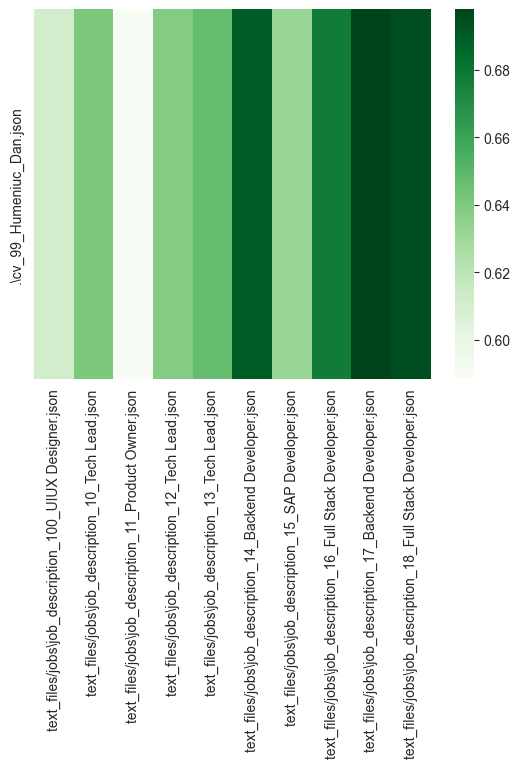

In [6]:
cv_ids, cv_texts, cv_titles = read_folder('.')

cv_embeddings = client.models.embed_content(
    model='models/text-embedding-004',
    contents=cv_texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))

# Set up the embeddings in a dataframe.
df_cv = pd.DataFrame([e.values for e in cv_embeddings.embeddings], index=[cur_title for cur_title in cv_titles])
# df_job = pd.DataFrame([e.values for e in job_embeddings.embeddings], index=[cur_title for cur_title in job_titles])

# Perform the similarity calculation
sim = df_cv @ df_job.T
mini = sim.min().min()
maxi = sim.max().max()

sns.heatmap(sim, vmin=mini, vmax=maxi, cmap='Greens')